# **project deep learning **

Loading and preparing data...

Data Split:
Training samples: 136 (69.7%)
Validation samples: 29 (14.9%)
Testing samples: 30 (15.4%)

Creating model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      2,944 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 1)         │         33 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity (Dense)    │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,194 (63.26 KB)

 Trainable params: 15,810 (61.76 KB)

 Non-trainable params: 384 (1.50 KB)


Training model...
Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - classification_accuracy: 0.4273 - classification_auc: 0.5405 - classification_loss: 1.1270 - loss: 4.2039 - severity_loss: 8.8339 - severity_mae: 2.3902 - val_classification_accuracy: 0.4138 - val_classification_auc: 0.5909 - val_classification_loss: 0.7682 - val_loss: 5.0124 - val_severity_loss: 11.4978 - val_severity_mae: 3.2564 - learning_rate: 5.0000e-04
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - classification_accuracy: 0.3504 - classification_auc: 0.5183 - classification_loss: 1.1812 - loss: 3.9566 - severity_loss: 8.0946 - severity_mae: 2.4318 - val_classification_accuracy: 0.4483 - val_classification_auc: 0.6364 - val_classification_loss: 0.7644 - val_loss: 4.1729 - val_severity_loss: 9.3877 - val_severity_mae: 2.9397 - learning_rate: 5.0000e-04
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - classification_accuracy: 0.4455 - classification_auc: 0.6612 - classification_loss: 0.9859 - loss: 3.67

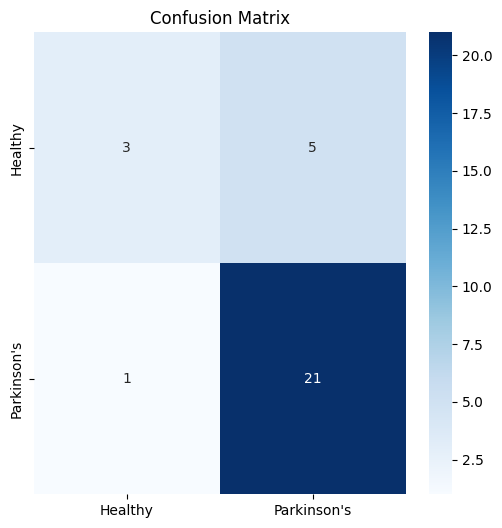

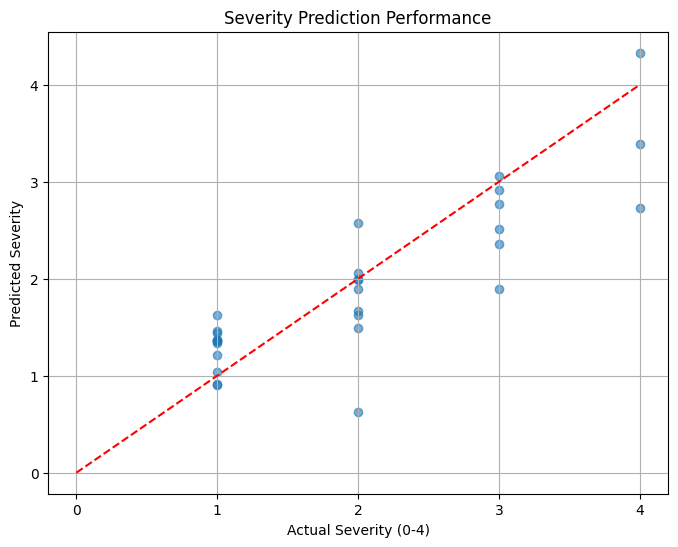

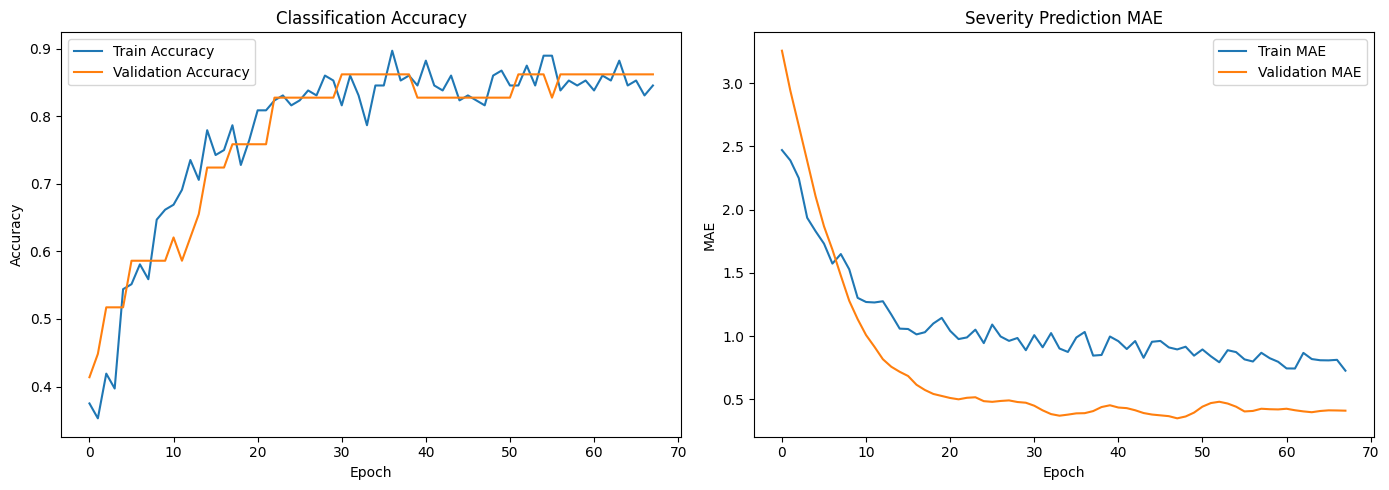


Model saved as parkinson_voice_model.h5


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading and Preparation
def load_and_prepare_data(filepath):
    # Load the dataset
    df = pd.read_csv(filepath)

    # Create simulated severity scores (0-4 scale) based on voice measurements
    # Higher values indicate more severe Parkinson's symptoms
    df['severity'] = (
        0.5 * df['MDVP:Jitter(%)'] * 100 +
        0.3 * df['MDVP:Shimmer'] * 100 +
        0.2 * df['NHR'] * 200 +
        0.1 * df['RPDE'] * 10
    ).clip(lower=0, upper=4)

    # Convert severity to integer levels (0-4)
    df['severity'] = pd.cut(df['severity'],
                           bins=[-1, 0.5, 1.5, 2.5, 3.5, 5],
                           labels=[0, 1, 2, 3, 4]).astype(int)

    # Features - exclude name and status columns
    X = df.drop(['name', 'status', 'severity'], axis=1)
    y_binary = df['status']  # 0: healthy, 1: Parkinson's
    y_severity = df['severity']  # 0-4 severity scale

    return X, y_binary, y_severity

# 2. Data Splitting
def split_data(X, y_binary, y_severity):
    # First split: 70% train, 30% temp
    X_train, X_temp, y_binary_train, y_binary_temp, y_severity_train, y_severity_temp = train_test_split(
        X, y_binary, y_severity, test_size=0.3, random_state=42, stratify=y_binary)

    # Second split: 50% of temp for val, 50% for test (15% each)
    X_val, X_test, y_binary_val, y_binary_test, y_severity_val, y_severity_test = train_test_split(
        X_temp, y_binary_temp, y_severity_temp, test_size=0.5, random_state=42, stratify=y_binary_temp)

    print(f"\nData Split:")
    print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"Validation samples: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
    print(f"Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

    return X_train, X_val, X_test, y_binary_train, y_binary_val, y_binary_test, y_severity_train, y_severity_val, y_severity_test

# 3. Model Architecture
def create_parkinson_model(input_shape):
    inputs = Input(shape=(input_shape,))

    # Shared feature extraction layers
    x = Dense(128, activation='relu', kernel_initializer='he_normal')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(64, activation='relu', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Classification branch (binary: healthy vs Parkinson's)
    cls_branch = Dense(32, activation='relu')(x)
    cls_branch = Dropout(0.2)(cls_branch)
    cls_output = Dense(1, activation='sigmoid', name='classification')(cls_branch)

    # Regression branch (severity prediction 0-4)
    reg_branch = Dense(32, activation='relu')(x)
    reg_branch = Dropout(0.2)(reg_branch)
    reg_output = Dense(1, activation='linear', name='severity')(reg_branch)

    model = Model(inputs=inputs, outputs=[cls_output, reg_output])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss={'classification': 'binary_crossentropy', 'severity': 'mse'},
        metrics={
            'classification': ['accuracy', tf.keras.metrics.AUC(name='auc')],
            'severity': ['mae']
        },
        loss_weights={'classification': 0.6, 'severity': 0.4}
    )

    return model

# 4. Training and Evaluation
def train_and_evaluate(model, X_train, X_val, X_test,
                      y_binary_train, y_binary_val, y_binary_test,
                      y_severity_train, y_severity_val, y_severity_test):

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
    ]

    history = model.fit(
        X_train,
        {'classification': y_binary_train, 'severity': y_severity_train},
        validation_data=(X_val, {'classification': y_binary_val, 'severity': y_severity_val}),
        epochs=200,
        batch_size=16,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate on test set
    print("\nTest Set Evaluation:")
    test_results = model.evaluate(
        X_test,
        {'classification': y_binary_test, 'severity': y_severity_test},
        verbose=0
    )

    # Generate predictions
    y_pred_binary, y_pred_severity = model.predict(X_test)
    y_pred_binary = (y_pred_binary > 0.5).astype(int)

    return model, history, test_results, y_pred_binary, y_pred_severity

# 5. Visualization Functions
def plot_results(history, y_binary_test, y_pred_binary, y_severity_test, y_pred_severity):
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_binary_test, y_pred_binary,
                              target_names=['Healthy', 'Parkinson\'s']))

    # Confusion matrix
    plt.figure(figsize=(6,6))
    sns.heatmap(confusion_matrix(y_binary_test, y_pred_binary),
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy', 'Parkinson\'s'],
                yticklabels=['Healthy', 'Parkinson\'s'])
    plt.title('Confusion Matrix')
    plt.show()

    # Severity prediction plot
    plt.figure(figsize=(8,6))
    plt.scatter(y_severity_test, y_pred_severity, alpha=0.6)
    plt.plot([0, 4], [0, 4], 'r--')
    plt.xticks([0, 1, 2, 3, 4])
    plt.yticks([0, 1, 2, 3, 4])
    plt.xlabel('Actual Severity (0-4)')
    plt.ylabel('Predicted Severity')
    plt.title('Severity Prediction Performance')
    plt.grid(True)
    plt.show()

    # Training history
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['classification_accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_classification_accuracy'], label='Validation Accuracy')
    plt.title('Classification Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['severity_mae'], label='Train MAE')
    plt.plot(history.history['val_severity_mae'], label='Validation MAE')
    plt.title('Severity Prediction MAE')
    plt.ylabel('MAE')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Main Execution
if __name__ == "__main__":
    # 1. Load and prepare data
    print("Loading and preparing data...")
    data_path = "/content/parkinsons.data"  # Update with your file path
    X, y_binary, y_severity = load_and_prepare_data(data_path)

    # 2. Normalize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3. Split data
    X_train, X_val, X_test, y_binary_train, y_binary_val, y_binary_test,y_severity_train, y_severity_val, y_severity_test = split_data(X_scaled, y_binary, y_severity)

    # 4. Create model
    print("\nCreating model...")
    model = create_parkinson_model(X_train.shape[1])
    model.summary()

    # 5. Train and evaluate
    print("\nTraining model...")
    model, history, test_results, y_pred_binary, y_pred_severity = train_and_evaluate(
        model, X_train, X_val, X_test,
        y_binary_train, y_binary_val, y_binary_test,
        y_severity_train, y_severity_val, y_severity_test
    )

    # Print evaluation metrics
    print(f"\nFinal Test Metrics:")
    print(f"Classification Accuracy: {test_results[3]:.4f}")
    print(f"Classification AUC: {test_results[4]:.4f}")
    print(f"Severity MAE: {test_results[5]:.4f}")

    # 6. Visualize results
    plot_results(history, y_binary_test, y_pred_binary, y_severity_test, y_pred_severity)

    # 7. Save model
    model.save("parkinson_voice_model.h5")
    print("\nModel saved as parkinson_voice_model.h5")